In [1]:
# Lab: Mạng Nơ-ron Nhân tạo (ANN) với PyTorch
# Thử trên tập data MNIST và Catanddog


import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import os
import matplotlib.pyplot as plt

# Đặt seed để kết quả ổn định hơn (tùy chọn)
torch.manual_seed(42)
np.random.seed(42)

# ==================== PHẦN 1: TẠO DỮ LIỆU MNIST ====================

print("Loading MNIST dataset...")
# Tải dữ liệu MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize the data
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Chọn một số mẫu để huấn luyện nhanh hơn (tùy chọn)
train_subset, _ = torch.utils.data.random_split(train_dataset, [10000, len(train_dataset) - 10000])
test_subset, _ = torch.utils.data.random_split(test_dataset, [2000, len(test_dataset) - 2000])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

# ==================== PHẦN 2: XÂY DỰNG MÔ HÌNH ANN ====================

class ANN_MNIST(nn.Module):
    def __init__(self):
        super(ANN_MNIST, self).__init__()
        # Flatten image 28x28 -> 784
        self.layer1 = nn.Linear(784, 128)  # Đầu vào 784, ẩn 128
        self.relu = nn.ReLU()              # Công tắc ReLU
        self.dropout = nn.Dropout(0.2)     # Dropout để tránh overfitting
        self.layer2 = nn.Linear(128, 64)   # Ẩn 128, ẩn 64
        self.layer3 = nn.Linear(64, 10)    # Ẩn 64, đầu ra 10 (cho 10 chữ số)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        x = self.layer1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.layer3(x)  # Không dùng sigmoid ở đầu ra vì dùng CrossEntropyLoss
        return x

# ==================== PHẦN 3: HUẤN LUYỆN MÔ HÌNH MNIST ====================

print("Training MNIST model...")
model_mnist = ANN_MNIST()

# Định nghĩa hàm mất mát và tối ưu hóa
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_mnist.parameters(), lr=0.001)

# Huấn luyện
epochs = 10
train_losses_mnist = []
train_accuracies_mnist = []

for epoch in range(epochs):
    model_mnist.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = model_mnist(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
    
    # Tính độ chính xác trên tập huấn luyện
    accuracy = 100. * correct / total
    train_losses_mnist.append(running_loss / len(train_loader))
    train_accuracies_mnist.append(accuracy)
    
    print(f'Epoch [{epoch+1}/{epochs}] - Loss: {running_loss/len(train_loader):.4f}, Accuracy: {accuracy:.2f}%')

# ==================== PHẦN 4: KIỂM TRA MÔ HÌNH MNIST ====================

print("Evaluating MNIST model...")
model_mnist.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model_mnist(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

accuracy_mnist = 100. * correct / total
print(f'Do chính xác MNIST: {accuracy_mnist:.2f}%')

Loading MNIST dataset...


100%|██████████| 9.91M/9.91M [00:49<00:00, 199kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 96.6kB/s]
100%|██████████| 1.65M/1.65M [00:10<00:00, 163kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.27MB/s]


Training MNIST model...
Epoch [1/10], Step [100/157], Loss: 0.3466
Epoch [1/10] - Loss: 0.6433, Accuracy: 80.79%
Epoch [2/10], Step [100/157], Loss: 0.2472
Epoch [2/10] - Loss: 0.2898, Accuracy: 90.78%
Epoch [3/10], Step [100/157], Loss: 0.1704
Epoch [3/10] - Loss: 0.2207, Accuracy: 93.28%
Epoch [4/10], Step [100/157], Loss: 0.2585
Epoch [4/10] - Loss: 0.1724, Accuracy: 94.75%
Epoch [5/10], Step [100/157], Loss: 0.1415
Epoch [5/10] - Loss: 0.1380, Accuracy: 95.58%
Epoch [6/10], Step [100/157], Loss: 0.1934
Epoch [6/10] - Loss: 0.1142, Accuracy: 96.52%
Epoch [7/10], Step [100/157], Loss: 0.0416
Epoch [7/10] - Loss: 0.1074, Accuracy: 96.66%
Epoch [8/10], Step [100/157], Loss: 0.1292
Epoch [8/10] - Loss: 0.0875, Accuracy: 97.22%
Epoch [9/10], Step [100/157], Loss: 0.0674
Epoch [9/10] - Loss: 0.0757, Accuracy: 97.56%
Epoch [10/10], Step [100/157], Loss: 0.0494
Epoch [10/10] - Loss: 0.0706, Accuracy: 97.83%
Evaluating MNIST model...
Do chính xác MNIST: 95.60%


In [12]:
# ==================== PHẦN 5: TẠO DỮ LIỆU CATANDDOG ====================

print("\nLoading CatAndDog dataset...")
# Tạo transform cho CatAndDog dataset
transform_catdog = transforms.Compose([
    transforms.Resize((32, 32)),  # Resize ảnh về 32x32
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Tải dữ liệu từ thư mục training_set và test_set
train_dataset_catdog = ImageFolder(root='training_set', transform=transform_catdog)
test_dataset_catdog = ImageFolder(root='test_set', transform=transform_catdog)

# Tạo DataLoader cho CatAndDog
catdog_train_loader = DataLoader(train_dataset_catdog, batch_size=32, shuffle=True)
catdog_test_loader = DataLoader(test_dataset_catdog, batch_size=32, shuffle=False)

# ==================== PHẦN 6: XÂY DỰNG MÔ HÌNH ANN CHO CATANDDOG ====================

class ANN_CatDog(nn.Module):
    def __init__(self):
        super(ANN_CatDog, self).__init__()
        # Flatten image 32x32x3 -> 3072
        self.layer1 = nn.Linear(3072, 512)  # Đầu vào 3072, ẩn 512
        self.relu = nn.ReLU()               # Công tắc ReLU
        self.dropout = nn.Dropout(0.3)      # Dropout để tránh overfitting
        self.layer2 = nn.Linear(512, 256)   # Ẩn 512, ẩn 256
        self.layer3 = nn.Linear(256, 2)     # Ẩn 256, đầu ra 2 (cat/dog)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        x = self.layer1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.layer3(x)  # Không dùng sigmoid ở đầu ra vì dùng CrossEntropyLoss
        return x

# ==================== PHẦN 7: HUẤN LUYỆN MÔ HÌNH CATANDDOG ====================

print("Training CatAndDog model...")
model_catdog = ANN_CatDog()

# Định nghĩa hàm mất mát và tối ưu hóa
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_catdog.parameters(), lr=0.001)

# Huấn luyện
epochs = 10
train_losses_catdog = []
train_accuracies_catdog = []

for epoch in range(epochs):
    model_catdog.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (images, labels) in enumerate(catdog_train_loader):
        optimizer.zero_grad()
        outputs = model_catdog(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        if (i + 1) % 50 == 0:
            print(f'CatAndDog Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(catdog_train_loader)}], Loss: {loss.item():.4f}')
    
    # Tính độ chính xác trên tập huấn luyện
    accuracy = 100. * correct / total
    train_losses_catdog.append(running_loss / len(catdog_train_loader))
    train_accuracies_catdog.append(accuracy)
    
    print(f'CatAndDog Epoch [{epoch+1}/{epochs}] - Loss: {running_loss/len(catdog_train_loader):.4f}, Accuracy: {accuracy:.2f}%')

# ==================== PHẦN 8: KIỂM TRA MÔ HÌNH CATANDDOG ====================

print("Evaluating CatAndDog model...")
model_catdog.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in catdog_test_loader:
        outputs = model_catdog(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

accuracy_catdog = 100. * correct / total
print(f'Do chính xác CatAndDog: {accuracy_catdog:.2f}%')


Loading CatAndDog dataset...
Training CatAndDog model...
CatAndDog Epoch [1/10], Step [50/251], Loss: 0.6985
CatAndDog Epoch [1/10], Step [100/251], Loss: 0.5992
CatAndDog Epoch [1/10], Step [150/251], Loss: 0.6327
CatAndDog Epoch [1/10], Step [200/251], Loss: 0.6417
CatAndDog Epoch [1/10], Step [250/251], Loss: 0.6167
CatAndDog Epoch [1/10] - Loss: 0.6976, Accuracy: 57.31%
CatAndDog Epoch [2/10], Step [50/251], Loss: 0.6515
CatAndDog Epoch [2/10], Step [100/251], Loss: 0.6595
CatAndDog Epoch [2/10], Step [150/251], Loss: 0.6232
CatAndDog Epoch [2/10], Step [200/251], Loss: 0.6180
CatAndDog Epoch [2/10], Step [250/251], Loss: 0.7198
CatAndDog Epoch [2/10] - Loss: 0.6478, Accuracy: 62.40%
CatAndDog Epoch [3/10], Step [50/251], Loss: 0.6315
CatAndDog Epoch [3/10], Step [100/251], Loss: 0.8478
CatAndDog Epoch [3/10], Step [150/251], Loss: 0.6106
CatAndDog Epoch [3/10], Step [200/251], Loss: 0.5911
CatAndDog Epoch [3/10], Step [250/251], Loss: 0.5935
CatAndDog Epoch [3/10] - Loss: 0.6338,

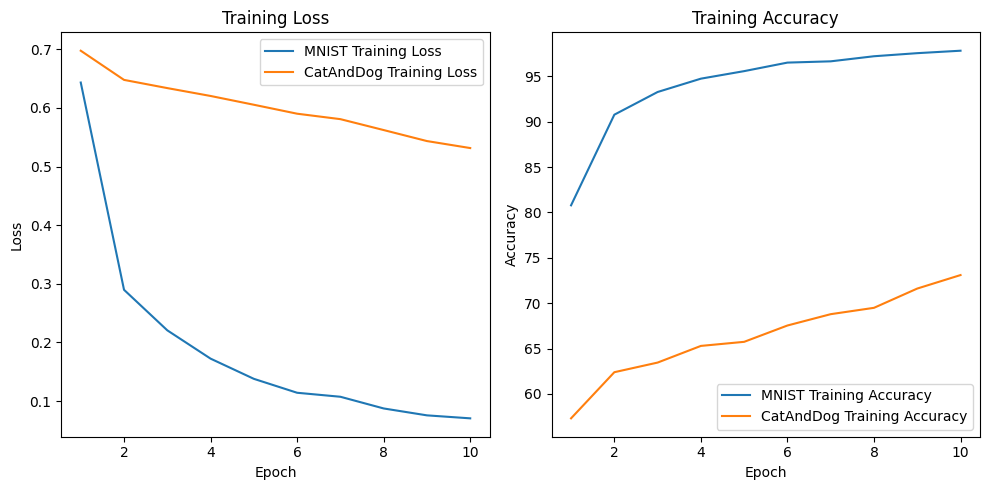

Training comparison saved to training_comparison.png


In [13]:
# ==================== VẼ BIỂU ĐỒ ====================

# Vẽ đồ thị loss và accuracy
epochs = range(1, epochs+1)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses_mnist, label='MNIST Training Loss')
plt.plot(epochs, train_losses_catdog, label='CatAndDog Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies_mnist, label='MNIST Training Accuracy')
plt.plot(epochs, train_accuracies_catdog, label='CatAndDog Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('training_comparison.png')
plt.show()

print("Training comparison saved to training_comparison.png")